# **# 1. Business Understanding**


The objective is to automate the identification of iris flower species based on physical measurements.

Goal: Use morphological features (sepal and petal dimensions) to accurately predict which of the three species a flower belongs to.

Success Criteria: Achieve high classification accuracy (typically >95% for this classic dataset).

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
df = pd.read_csv('Iris.csv')

# Drop Id for analysis as it provides no predictive value
df_eda = df.drop('Id', axis=1)

# Summary statistics and metadata
print("--- Data Info ---")
print(df_eda.info())


--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB
None


In [3]:
print("\n--- Summary Statistics ---")
print(df_eda.describe())


--- Summary Statistics ---
       SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count     150.000000    150.000000     150.000000    150.000000
mean        5.843333      3.054000       3.758667      1.198667
std         0.828066      0.433594       1.764420      0.763161
min         4.300000      2.000000       1.000000      0.100000
25%         5.100000      2.800000       1.600000      0.300000
50%         5.800000      3.000000       4.350000      1.300000
75%         6.400000      3.300000       5.100000      1.800000
max         7.900000      4.400000       6.900000      2.500000


Count (150): Confirms a complete dataset with no missing values across all four features.

Mean & Median (50%): Shows the average and middle values. For PetalLengthCm, the mean (3.76) is lower than the median (4.35), indicating a cluster of very small values (typically the Setosa species).

Standard Deviation (std): Indicates how much the data varies. PetalLengthCm has the highest variation (1.76), making it the most useful feature for distinguishing between species.

Range (Min/Max): Defines the boundaries of the data. Petal lengths range from a tiny 1.0 cm to a much larger 6.9 cm.

Quartiles (25%/75%): Shows where the bulk of the data lies. For example, 75% of all samples have a PetalWidthCm of 1.8 cm or less.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Check for missing values (Iris dataset typically has none, but it's good practice)
print("\nMissing values:\n", df.isnull().sum())

# 2. Feature Selection
X = df.drop('Species', axis=1) # Features (Sepal/Petal lengths and widths)
y = df['Species']              # Target variable

# 3. Encode the target variable (strings to integers)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 4. Train/Test Split
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"\nTraining data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")


Missing values:
 Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Training data shape: (120, 5)
Testing data shape: (30, 5)


# Visualizing relationships using a pair plot

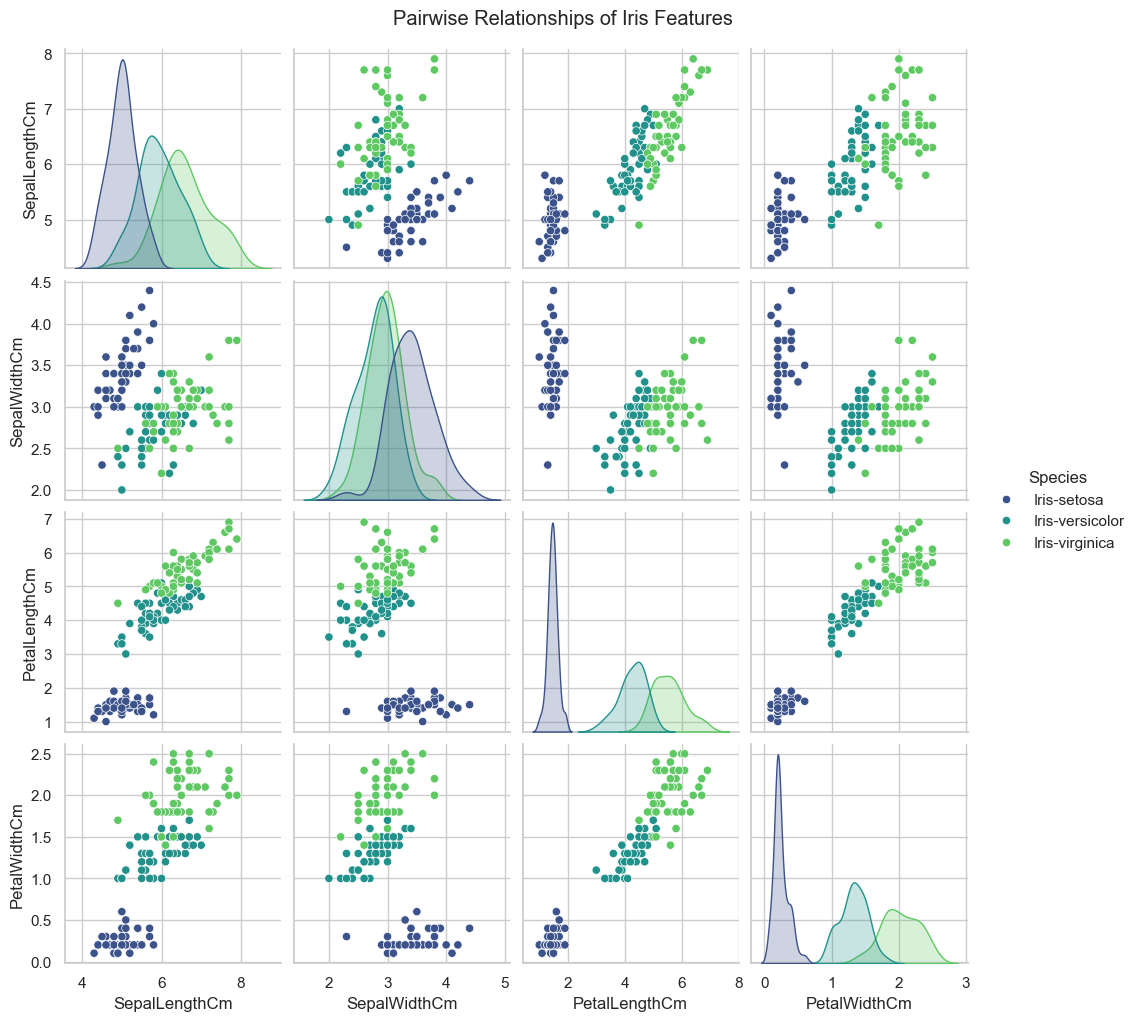

In [5]:

sns.set_theme(style="whitegrid")
sns.pairplot(df_eda, hue='Species', palette='viridis')
plt.suptitle("Pairwise Relationships of Iris Features", y=1.02)
plt.show()

The pairplot  provides a visual map of how different features distinguish the three iris species.

Feature Importance: The diagonal plots (KDEs) show that Petal Length and Petal Width are the best "discriminators" because the species curves (colors) are more separated than in the sepal plots.

Species Clustering:

Iris-setosa (Dark Blue): Completely isolated in almost every plot, making it the easiest to classify.

Iris-versicolor (Teal) & Iris-virginica (Green): These show some overlap, particularly in sepal measurements, indicating they are more physically similar and harder for the model to distinguish.

Correlation: The scatter plots show a strong linear relationship between petal length and width—as one increases, the other typically does as well.

# Feature Correlation Heatmap

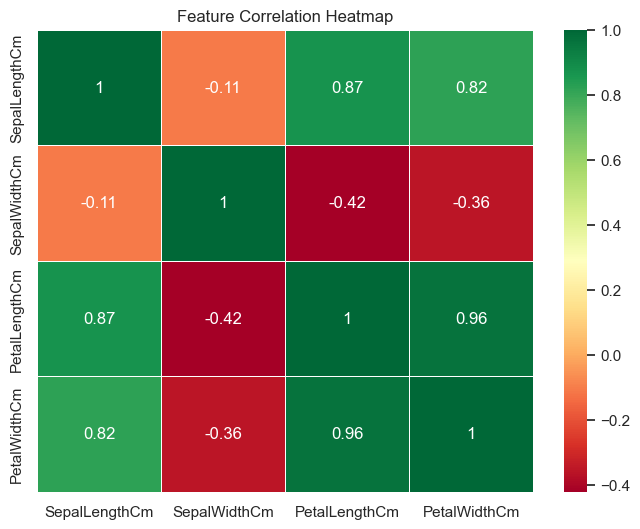

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Drop non-numeric columns for correlation calculation
corr_matrix = df.drop(['Id', 'Species'], axis=1).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

# Model training 

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score


# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions and evaluate
y_pred = model.predict(X_test)

print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nDetailed Performance Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 100.00%

Detailed Performance Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



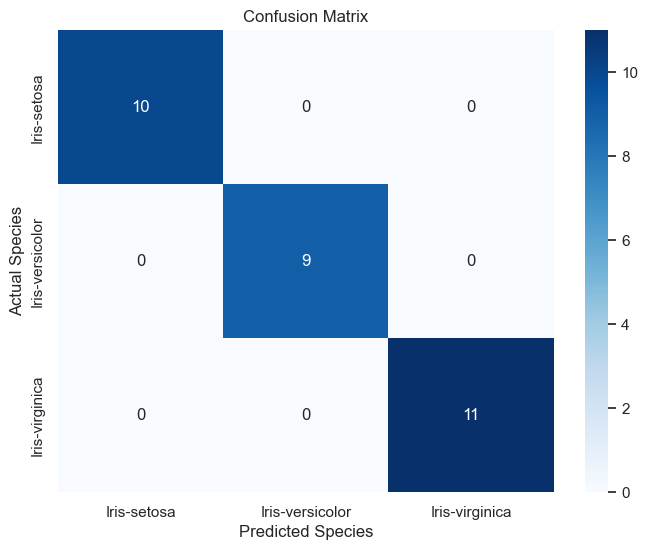

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix


# Plot Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
# Now confusion_matrix will be defined!
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix')
plt.ylabel('Actual Species')
plt.xlabel('Predicted Species')
plt.show()

Accuracy (100%): The computer looked at 30 new flowers it had never seen before and guessed the correct name for every single one of them.

Precision (1.00): When the computer said a flower was a certain type, it was right 100% of the time. It never gave a flower the wrong name.

Recall (1.00): The computer found every single flower for each group. For example, there were 10 Setosa flowers, and it found all 10 without missing any.

F1-Score (1.00): This is just a final score that combines Precision and Recall. Since both were perfect, this is perfect too.

Support: This tells us how many flowers of each type were in the test (10 Setosa, 9 Versicolor, and 11 Virginica).